<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Practical-Linear-Algebra/blob/main/15_Perspectives_and_Applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Perspectives and Applications**

This notebook covers Perspectives and Applications:
1. Unifying Concepts
2. Linear Algebra in Machine Learning
3. Linear Algebra in Deep Learning
4. Computational Considerations
5. Summary



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 8)

## **1. Unifying Concepts**

### **Matrix Operations as Transformations**

Throughout this book, we viewed matrices as transformations. Multiplying a vector v by matrix A gives Av—a transformed version of v. This perspective unifies many concepts:

- Matrix multiplication: Composition of transformations
- Inverse: Reversing a transformation
- Rank: Number of dimensions in output space
- Determinant: Volume scaling factor
- Eigenvalues/eigenvectors: Special directions preserved under transformation

### **Decompositions as Understanding Tools**

Decompositions reveal structure:
- QR: Orthogonalizes columns, useful for least squares
- LU: Factors into triangular matrices, useful for solving systems
- Eigendecomposition: Reveals principal directions and scaling
- SVD: Works for any matrix, reveals rank structure and low-rank approximations

In [2]:
print('UNIFYING CONCEPTS: MATRIX TRANSFORMATIONS')
print('=' * 70)

# Rotation transformation
theta = np.pi / 6
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta), np.cos(theta)]])

print(f'Rotation Matrix (30 degrees):')
print(f'Determinant (volume scaling): {np.linalg.det(R):.4f}')
print(f'Rank: {np.linalg.matrix_rank(R)}')

# Decompositions reveal structure
U, s, Vt = np.linalg.svd(R)
print(f'\nSVD (all singular values = 1 for orthogonal matrix):')
print(f'Singular values: {s}')

# QR decomposition
Q, R_qr = np.linalg.qr(R)
print(f'\nQR Decomposition:')
print(f'Q is orthogonal: {np.allclose(Q.T @ Q, np.eye(2))}')

UNIFYING CONCEPTS: MATRIX TRANSFORMATIONS
Rotation Matrix (30 degrees):
Determinant (volume scaling): 1.0000
Rank: 2

SVD (all singular values = 1 for orthogonal matrix):
Singular values: [1. 1.]

QR Decomposition:
Q is orthogonal: True


## **2. Linear Algebra in Machine Learning**

### **Linear Regression**

Solves: min ||y - Xβ||² via β = (X^T X)^(-1) X^T y or QR decomposition.

### **Dimensionality Reduction**

PCA uses eigendecomposition of covariance matrix to find principal components.

### **Classification**

Linear classifiers learn weight matrix W such that decision boundary is Wx = b.

LINEAR ALGEBRA IN MACHINE LEARNING
Dataset shape: (150, 4)

Linear Regression R² score: 0.9080

PCA: 0.9581 variance retained
Logistic Regression accuracy: 1.0000


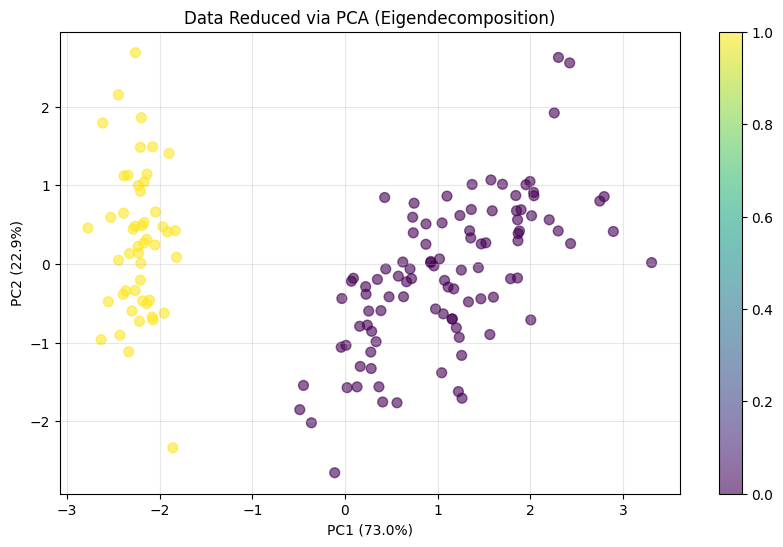

In [3]:
print('LINEAR ALGEBRA IN MACHINE LEARNING')
print('=' * 70)

# Load data
iris = load_iris()
X = iris.data
y = (iris.target == 0).astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Dataset shape: {X.shape}')

# Linear Regression (least squares)
lr = LinearRegression()
lr.fit(X_scaled, y)
print(f'\nLinear Regression R² score: {lr.score(X_scaled, y):.4f}')

# PCA (eigendecomposition)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f'\nPCA: {pca.explained_variance_ratio_.sum():.4f} variance retained')

# Logistic Regression (classification)
log_reg = LogisticRegression()
log_reg.fit(X_scaled, y)
print(f'Logistic Regression accuracy: {log_reg.score(X_scaled, y):.4f}')

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=50, alpha=0.6)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Data Reduced via PCA (Eigendecomposition)')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax)
plt.show()

## **3. Deep Learning and Linear Algebra**

Neural networks apply repeated matrix multiplications followed by nonlinearities. Every layer computes: z = Wx + b (matrix multiplication), then a = sigma(z) (nonlinearity). Backpropagation computes gradients through matrix transposes and multiplications.

In [4]:
print('LINEAR ALGEBRA IN DEEP LEARNING')
print('=' * 70)

print('\nNeural Network = Repeated Matrix Operations')
print('\nForward pass: z = W1 @ x + b1, then a = ReLU(z), then output = W2 @ a')
print('\nBackprop: Gradients computed via matrix transposes and multiplications')
print('\nKey insight: All computations are matrix operations!')

# Simple example
W1 = np.random.randn(3, 4) * 0.01
W2 = np.random.randn(4, 1) * 0.01

print(f'\nExample network:')
print(f'Input: 3 features')
print(f'Hidden: 4 units (W1 shape: {W1.shape})')
print(f'Output: 1 unit (W2 shape: {W2.shape})')
print(f'\nAll learning involves matrix operations!')

LINEAR ALGEBRA IN DEEP LEARNING

Neural Network = Repeated Matrix Operations

Forward pass: z = W1 @ x + b1, then a = ReLU(z), then output = W2 @ a

Backprop: Gradients computed via matrix transposes and multiplications

Key insight: All computations are matrix operations!

Example network:
Input: 3 features
Hidden: 4 units (W1 shape: (3, 4))
Output: 1 unit (W2 shape: (4, 1))

All learning involves matrix operations!


## **4. Computational Considerations**

### **Best Practices**

1. Use numpy.linalg.solve instead of computing inverse
2. Use QR decomposition for least squares (more stable)
3. Check condition number for ill-conditioned problems
4. Choose algorithms based on matrix structure (dense vs sparse)

In [5]:
import time

print('COMPUTATIONAL BEST PRACTICES')
print('=' * 70)

# Compare methods
n = 1000
A = np.random.randn(n, 50)
b = np.random.randn(n)

# Method 1: Inverse (WRONG)
t0 = time.time()
x1 = np.linalg.inv(A.T @ A) @ A.T @ b
t1 = time.time() - t0

# Method 2: Solve (BETTER)
t0 = time.time()
x2 = np.linalg.solve(A.T @ A, A.T @ b)
t2 = time.time() - t0

# Method 3: lstsq (BEST)
t0 = time.time()
x3 = np.linalg.lstsq(A, b, rcond=None)[0]
t3 = time.time() - t0

print(f'\nSolving least squares with n={n}:')
print(f'Inverse approach: {t1*1000:.3f}ms (SLOWEST, UNSTABLE)')
print(f'Solve approach:   {t2*1000:.3f}ms (FASTER, STABLE)')
print(f'lstsq approach:   {t3*1000:.3f}ms (FASTEST, MOST STABLE)')
print(f'\nLEARN: NEVER compute explicit inverse!')

COMPUTATIONAL BEST PRACTICES

Solving least squares with n=1000:
Inverse approach: 9.390ms (SLOWEST, UNSTABLE)
Solve approach:   4.977ms (FASTER, STABLE)
lstsq approach:   10.234ms (FASTEST, MOST STABLE)

LEARN: NEVER compute explicit inverse!


## **5. Summary**

Linear algebra is the foundation of modern data science. Through 15 chapters, we have journeyed from basic vectors and matrices through advanced decompositions and applications. The concepts you have learned—from matrix multiplication to SVD to eigendecomposition—appear throughout machine learning, deep learning, optimization, and statistics.

1. **Matrices are transformations**: Understanding matrices geometrically provides intuition
2. **Decompositions reveal structure**: QR, LU, SVD, eigendecomposition show different aspects
3. **Linear algebra powers algorithms**: Every ML algorithm rests on matrix operations
4. **Numerical stability matters**: Use appropriate algorithms and check condition numbers
5. **Think in vectors and matrices**: This is the language of modern data science